Upload a grayscale or color image


Saving test.jpg to test.jpg


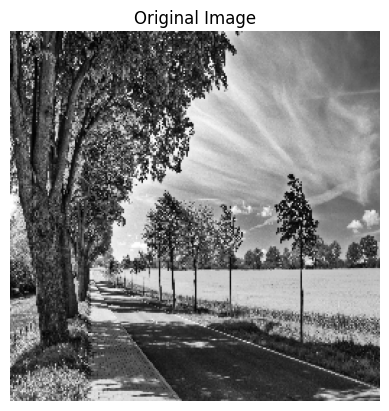


===== Compression Results =====
Original Size (bits): 524288
Compressed Size (bits): 387778
Compression Ratio: 1.35


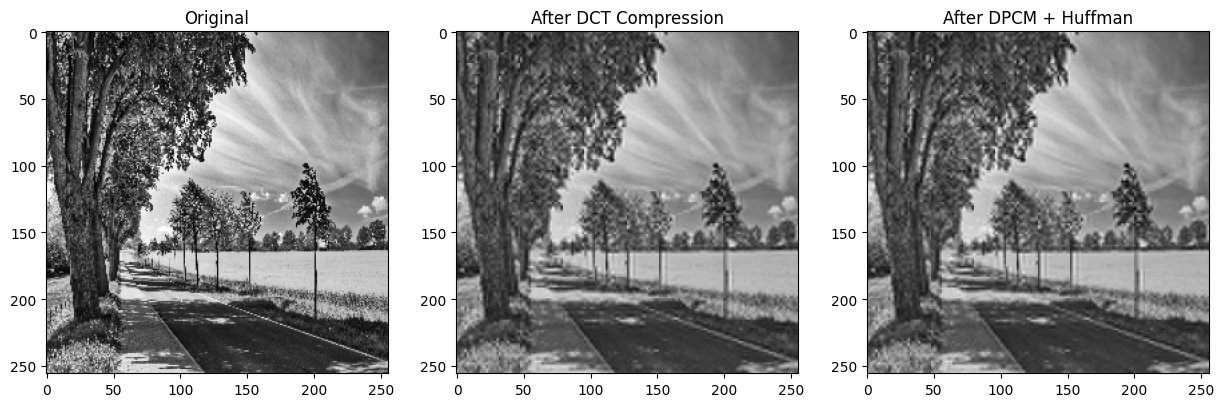

In [1]:
!pip -q install opencv-python

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from collections import Counter
import heapq

print("Upload a grayscale or color image")
uploaded = files.upload()

img_name = list(uploaded.keys())[0]
img = cv2.imread(img_name, cv2.IMREAD_GRAYSCALE)

img = cv2.resize(img, (256,256))
img = img.astype(np.float32)

plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

block_size = 8
h, w = img.shape
dct_image = np.zeros_like(img)

for i in range(0, h, block_size):
    for j in range(0, w, block_size):
        block = img[i:i+block_size, j:j+block_size]
        dct_block = cv2.dct(block)

        mask = np.zeros_like(dct_block)
        mask[:4,:4] = 1
        dct_block = dct_block * mask

        dct_image[i:i+block_size, j:j+block_size] = dct_block

reconstructed_dct = np.zeros_like(img)

for i in range(0, h, block_size):
    for j in range(0, w, block_size):
        block = dct_image[i:i+block_size, j:j+block_size]
        reconstructed_dct[i:i+block_size, j:j+block_size] = cv2.idct(block)

dpcm_encoded = np.zeros_like(reconstructed_dct)
prediction = np.zeros_like(reconstructed_dct)

for i in range(h):
    for j in range(w):
        if j == 0:
            pred = 0
        else:
            pred = reconstructed_dct[i, j-1]

        prediction[i,j] = pred
        dpcm_encoded[i,j] = reconstructed_dct[i,j] - pred

dpcm_decoded = np.zeros_like(dpcm_encoded)

for i in range(h):
    for j in range(w):
        if j == 0:
            pred = 0
        else:
            pred = dpcm_decoded[i,j-1]

        dpcm_decoded[i,j] = dpcm_encoded[i,j] + pred

data = dpcm_encoded.flatten().astype(int)

class Node:
    def __init__(self, freq, symbol=None, left=None, right=None):
        self.freq = freq
        self.symbol = symbol
        self.left = left
        self.right = right
    def __lt__(self, other):
        return self.freq < other.freq

freq = Counter(data)
heap = [Node(f, s) for s, f in freq.items()]
heapq.heapify(heap)

while len(heap) > 1:
    n1 = heapq.heappop(heap)
    n2 = heapq.heappop(heap)
    merged = Node(n1.freq+n2.freq, left=n1, right=n2)
    heapq.heappush(heap, merged)

root = heap[0]

huffman_codes = {}
def generate_codes(node, code=""):
    if node is None:
        return
    if node.symbol is not None:
        huffman_codes[node.symbol] = code
    generate_codes(node.left, code+"0")
    generate_codes(node.right, code+"1")

generate_codes(root)
encoded_bits = "".join(huffman_codes[val] for val in data)
original_bits = img.size * 8
compressed_bits = len(encoded_bits)

compression_ratio = original_bits / compressed_bits

print("\n===== Compression Results =====")
print("Original Size (bits):", original_bits)
print("Compressed Size (bits):", compressed_bits)
print("Compression Ratio:", round(compression_ratio,2))

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(reconstructed_dct, cmap='gray')
plt.title("After DCT Compression")

plt.subplot(1,3,3)
plt.imshow(dpcm_decoded, cmap='gray')
plt.title("After DPCM + Huffman")

plt.show()